#*Milestone 1: Core Implementation + Data/Task Plan + Dry Run*




# ⚙️ Run Instructions

To ensure the project executes correctly and produces the expected results, please follow these steps within the Google Colab environment:

---

### 1. Environment Preparation

* **Open the Notebook:** Load the `miniproject.ipynb` file in Google Colab.
* **Set Runtime:** Ensure the runtime type is set to **Python 3**.
* **Hardware Acceleration (Optional):** Enable **GPU** (Runtime > Change runtime type > GPU) for faster processing during the Dry Run phase.

---

### 2. Library Initialization

* **Import Libraries:**
Execute the first cell to import all necessary libraries (`torch`, `pandas`, `sklearn`, etc.). This is a mandatory step for the subsequent code to function.

---


### 3. Core Implementation & Model Architecture
* **Module Definitions:** Execute the cells defining the essential components in this order: `scaled_dot_product_attention` function, `MultiHeadAttention` class, `PositionwiseFeedForward` class, and finally the `TransformerEncoderBlock` class.

* **Component Validation:**  Immediately run the Unit Test cells following each definition. These cells use Dummy Data (synthetic tensors) to verify the mathematical logic, masking behavior, and tensor shapes, ensuring each component is stable before processing real data.

---

### 4. Data Processing & Model Training

* **Data Preparation:** Execute the data loading and cleaning cells to prepare the dataset.
* **Dry Run:** Finally, run the **Dry Run** section to observe the model's performance on the pilot subset. The results, including **Loss Curves** and **Accuracy Metrics**, will be displayed at the end of the notebook.

---


In [ ]:
# import the necessary libraries
import os
import re
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import math

In [ ]:
import random
def set_seed (seed=42) :
  random. seed (seed)
  np. random. seed (seed)
  torch.manual_seed (seed)
  torch. cuda.manual_seed_all(seed)
# makes results more reproducible (slightly slower)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False
set_seed (42)

* ## Input Embeddings




In [ ]:

class InputEmbeddings(nn.Module):
    """
    Converts input token IDs to dense vector embeddings.
    Scales by sqrt(d_model) as in "Attention Is All You Need".
    """
    def __init__(self, d_model: int, vocab_size: int, pad_id: int = 0):
        """
        Args:
            d_model (int): Dimension of the embeddings (and the model).
            vocab_size (int): Size of the vocabulary.
            pad_id: ID for the pad tolkin.
        """
        super().__init__()
        self.d_model = d_model
        self.vocab_size = vocab_size
        self.pad_id = pad_id

        # Create the embedding layer
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=d_model,
            # padding_idx makes the PAD embedding stay zero and not get trained.
            padding_idx=pad_id
        )

    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:
        """
        Args:
            input_ids: Input tensor of token IDs (batch_size, seq_len).

        Returns:
            embeddings: Output tensor of embeddings (batch_size, seq_len, d_model).
        """
        #prevents crashes if the tensor accidentally becomes float.
        if input_ids.dtype != torch.long:
            input_ids = input_ids.long()

        # Look up embeddings and scale them.
        return self.embedding(input_ids) * math.sqrt(self.d_model)


* ## Positional Encoding

In [ ]:

class PositionalEncoding(nn.Module):
    """
    Injects positional information into the input embeddings.
    Uses sine and cosine functions of different frequencies.
    """
    def __init__(self, d_model: int, seq_len: int, dropout: float):
        """
        Args:
            d_model (int): Dimension of the embeddings (and the model).
            seq_len (int): Maximum sequence length.
            dropout (float): Dropout probability.
        """
        super().__init__()
        self.d_model = d_model
        self.seq_len = seq_len
        self.dropout = nn.Dropout(dropout)

        # Create a positional encoding matrix of shape (seq_len, d_model)
        pe = torch.zeros(seq_len, d_model)

        # Create a tensor representing positions (0, 1, 2, ..., seq_len-1)
        position = torch.arange(0, seq_len, dtype=torch.float).unsqueeze(1) # Shape: (seq_len, 1)

        # Calculate the division term for the frequencies
        # Original formula: 10000^(2i / d_model)
        # Log space equivalent: exp((2i / d_model) * log(10000)) = exp(2i * (-log(10000.0) / d_model))
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)) # Shape: (d_model / 2)

        # Apply sine to even indices (0, 2, 4, ...)
        pe[:, 0::2] = torch.sin(position * div_term)
        # Apply cosine to odd indices (1, 3, 5, ...)
        pe[:, 1::2] = torch.cos(position * div_term)

        # Add a batch dimension to the positional encoding matrix
        # Shape becomes (1, seq_len, d_model) so it can be easily added to input batches
        pe = pe.unsqueeze(0)

        # Register 'pe' as a buffer. Buffers are part of the model's state,
        # but are not considered parameters (not updated by the optimizer).
        self.register_buffer('pe', pe)

    def forward(self, x):
        """
        Forward pass to add positional encoding.

        Args:
            x (torch.Tensor): Input tensor (batch_size, seq_len, d_model).

        Returns:
            torch.Tensor: Output tensor with positional encoding added (batch_size, seq_len, d_model).
        """
        # Add positional encoding to the input tensor x.
        # self.pe is (1, seq_len, d_model). x is (batch_size, seq_len, d_model).
        # We only need pos encoding up to the actual sequence length in the batch `x.shape[1]`.
        # The `requires_grad_(False)` ensures this slicing operation doesn't track gradients for PE.
        x = x + (self.pe[:, :x.shape[1], :]).requires_grad_(False)
        # Apply dropout
        return self.dropout(x)

## 1. Scaled dot-product attention

In [ ]:


def scaled_dot_product_attention(query: torch.Tensor, key: torch.Tensor, value: torch.Tensor, mask: torch.Tensor = None, dropout: nn.Dropout = None):
    """
    Computes the Scaled Dot-Product Attention.

    Args:
        query (torch.Tensor): Query tensor, shape (batch_size, num_heads, seq_len_q, d_k)
        key (torch.Tensor): Key tensor, shape (batch_size, num_heads, seq_len_k, d_k)
        value (torch.Tensor): Value tensor, shape (batch_size, num_heads, seq_len_v, d_v)
        mask (torch.Tensor, optional): Mask tensor, shape broadcastable to
                                      (batch_size, num_heads, seq_len_q, seq_len_k).
                                       Positions with True or 1 will be masked (set to -inf). Defaults to None.
        dropout (nn.Dropout): Dropout layer to apply to attention weights. Defaults to None.

    Returns:
        torch.Tensor: The output tensor after attention, shape (batch_size, num_heads, seq_len_q, d_v)
        torch.Tensor: The attention weights, shape (batch_size, num_heads, seq_len_q, seq_len_k)
    """

    d_k = query.shape[-1]  # Dimension of keys/queries

    # 1. Calculate Attention Scores: (Q @ K^T)
    # Transpose key tensor for matrix multiplication: (..., seq_len_k, d_k) -> (..., d_k, seq_len_k)
    # Result shape: (batch_size, num_heads, seq_len_q, seq_len_k)

    ##### It performs a matrix multiplication (matmul) between the Queries and the Keys
    ##### This creates a "score" for every pair of words. A high score means the words are highly relevant to each other.
    attention_scores = torch.matmul(query, key.transpose(-2, -1))

    ##### We divide the scores by the square root of that dimension (dk). This "shrinks" the numbers back down so the model can stay "open-minded" about which words are important
    # 2. Scale the scores
    attention_scores = attention_scores / math.sqrt(d_k)

    # 3. Apply Mask (if provided)
    if mask is not None:
        # Apply the mask by filling positions with a large negative value (-1e9).
        # This ensures that these positions get near-zero probability after softmax.
        # The mask should have True/1 where positions should be masked.
        ##### This tells the model: "Ignore these specific words; they aren't useful".
        attention_scores = attention_scores.masked_fill(mask == True, -1e9) # Or mask == 1

    # 4. Apply Softmax to get Attention Weights
    # Softmax is applied on the last dimension (seq_len_k) to get probabilities over keys.
    # Shape: (batch_size, num_heads, seq_len_q, seq_len_k)
    attention_weights = torch.softmax(attention_scores, dim=-1)

    # 5. Apply Dropout
    if dropout is not None:
        attention_weights = dropout(attention_weights)

    # 6. Multiply weights by Values: (Weights @ V)
    # Shape: (batch_size, num_heads, seq_len_q, d_v)
    ##### The output is a new version of the data where the important words are "loud" and the unimportant words are "quiet"
    output = torch.matmul(attention_weights, value)

    ##### It gives back both the final data and the weight map so you can see what the model was looking at.
    return output, attention_weights

### Correctness checks

In [ ]:

print("\n--- Testing Scaled Dot-Product Attention ---")

# Parameters (Example)
batch_size_test = 2
num_heads_test = 8 # Number of attention heads
seq_len_q_test = 5 # Sequence length for queries
seq_len_k_test = 7 # Sequence length for keys/values
d_k_test = 64 // num_heads_test # Dimension of keys/queries per head
d_v_test = 64 // num_heads_test # Dimension of values per head
d_model_test = 64 # Total model dimension (d_k * num_heads)

# Dummy tensors
# Note the shape: (batch_size, num_heads, seq_len, dim_per_head)

##### torch.randn creates a block of random numbers.
##### The Shape: This creates a 4D tensor: [2 sentences, 8 heads, 5 words, 8 features per word].
dummy_q = torch.randn(batch_size_test, num_heads_test, seq_len_q_test, d_k_test)
dummy_k = torch.randn(batch_size_test, num_heads_test, seq_len_k_test, d_k_test)
dummy_v = torch.randn(batch_size_test, num_heads_test, seq_len_k_test, d_v_test)

print(f"Dummy Q shape: {dummy_q.shape}")
print(f"Dummy K shape: {dummy_k.shape}")
print(f"Dummy V shape: {dummy_v.shape}")

# --- Test without mask ---
print("\nTesting without mask:")
output_no_mask, weights_no_mask = scaled_dot_product_attention(dummy_q, dummy_k, dummy_v)
print(f"Output shape (no mask): {output_no_mask.shape}")       # Expected: [2, 8, 5, 8] (batch, heads, seq_q, dv)
print(f"Weights shape (no mask): {weights_no_mask.shape}")     # Expected: [2, 8, 5, 7] (batch, heads, seq_q, seq_k)
assert output_no_mask.shape == (batch_size_test, num_heads_test, seq_len_q_test, d_v_test)
assert weights_no_mask.shape == (batch_size_test, num_heads_test, seq_len_q_test, seq_len_k_test)


# Check if weights sum to 1 (approximately due to float precision)
assert torch.allclose(weights_no_mask.sum(dim=-1), torch.ones_like(weights_no_mask.sum(dim=-1))), "Weights don't sum to 1"
print("Test without mask passed.")

# --- Test with a simple look-ahead mask (for decoder self-attention) ---
# Create a mask for the query sequence length (seq_len_q_test = 5)
# Mask should be (seq_len_q, seq_len_k). Here seq_q=seq_k=5 for self-attention mask
mask_size = seq_len_q_test
# Create an upper triangular matrix (True above the diagonal)

##### creates a square grid where the top-right half is True and the rest is False.
##### Row 1 can only see word 1, Row 2 can see words 1 and 2....
##### This simulates a model that isn't allowed to "cheat" by looking at future words in a sentence.
look_ahead_mask = torch.triu(torch.ones(mask_size, mask_size), diagonal=1).bool()
# Expand mask to match attention score shape (batch_size, num_heads, seq_len_q, seq_len_k)
# We can use broadcasting: Unsqueeze for batch and head dimensions.
# Mask shape needs to be compatible: (1, 1, seq_len_q, seq_len_k) or similar

##### adds extra empty dimensions to the mask so it matches the 4D shape of the data.
dummy_mask = look_ahead_mask.unsqueeze(0).unsqueeze(0) # Shape: [1, 1, 5, 5]

# Adjust dummy K/V seq len to match Q seq len for self-attention mask test
dummy_k_masked = torch.randn(batch_size_test, num_heads_test, seq_len_q_test, d_k_test)
dummy_v_masked = torch.randn(batch_size_test, num_heads_test, seq_len_q_test, d_v_test)

print("\nTesting with look-ahead mask:")
print(f"Look-ahead mask shape: {dummy_mask.shape}")
print("Mask (True means masked):")
print(look_ahead_mask) # Show the basic mask structure

output_masked, weights_masked = scaled_dot_product_attention(dummy_q, dummy_k_masked, dummy_v_masked, mask=dummy_mask)
print(f"Output shape (masked): {output_masked.shape}")   # Expected: [2, 8, 5, 8]
print(f"Weights shape (masked): {weights_masked.shape}") # Expected: [2, 8, 5, 5]
assert output_masked.shape == (batch_size_test, num_heads_test, seq_len_q_test, d_v_test)
assert weights_masked.shape == (batch_size_test, num_heads_test, seq_len_q_test, seq_len_q_test) # seq_k adjusted
# Check if masked weights are zero
masked_positions_weights = weights_masked.masked_select(dummy_mask)
assert torch.all(masked_positions_weights == 0), "Masked positions have non-zero weights!"
# Check if non-masked weights sum to 1
# Note: Need to be careful here, sum across seq_k dim
assert torch.allclose(weights_masked.sum(dim=-1), torch.ones_like(weights_masked.sum(dim=-1))), "Weights don't sum to 1"

print("Test with mask passed.")


--- Testing Scaled Dot-Product Attention ---
Dummy Q shape: torch.Size([2, 8, 5, 8])
Dummy K shape: torch.Size([2, 8, 7, 8])
Dummy V shape: torch.Size([2, 8, 7, 8])

Testing without mask:
Output shape (no mask): torch.Size([2, 8, 5, 8])
Weights shape (no mask): torch.Size([2, 8, 5, 7])
Test without mask passed.

Testing with look-ahead mask:
Look-ahead mask shape: torch.Size([1, 1, 5, 5])
Mask (True means masked):
tensor([[False,  True,  True,  True,  True],
        [False, False,  True,  True,  True],
        [False, False, False,  True,  True],
        [False, False, False, False,  True],
        [False, False, False, False, False]])
Output shape (masked): torch.Size([2, 8, 5, 8])
Weights shape (masked): torch.Size([2, 8, 5, 5])
Test with mask passed.


## 2. Multi-head attention (MHA)


In [ ]:
import torch
import torch.nn as nn

class MultiHeadAttention(nn.Module):
    """
    Multi-Head Attention (core implementation; no nn.MultiheadAttention).

    Notation / shapes:
        B  : batch size
        Lq : query sequence length
        Lk : key/value sequence length
        D  : d_model
        H  : number of heads
        Dh : head dimension = D / H

    Inputs:
        query: (B, Lq, D)
        key:   (B, Lk, D)
        value: (B, Lk, D)
        mask:  broadcastable to (B, H, Lq, Lk), where True means "masked" (not allowed to attend)
    """

    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.0):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_head = d_model // num_heads

        # Linear projections
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # Output projection
        self.W_o = nn.Linear(d_model, d_model)

        # Dropout applied to attention weights inside scaled_dot_product_attention
        self.dropout = nn.Dropout(dropout)

        # store attention weights for debugging/analysis
        self.attention_weights = None

    def forward(
        self,
        query: torch.Tensor,
        key: torch.Tensor,
        value: torch.Tensor,
        mask: torch.Tensor = None,
        return_attention: bool = False
    ):
        """
        Returns:
            output: (B, Lq, D)
            attn: (B, H, Lq, Lk)
        """
        B = query.size(0)

        # 1) Linear projections: (B, L, D) -> (B, L, D)
        Q = self.W_q(query)
        K = self.W_k(key)
        V = self.W_v(value)

        # 2) Split heads: (B, L, D) -> (B, H, L, Dh)
        Q = Q.view(B, -1, self.num_heads, self.d_head).transpose(1, 2).contiguous()
        K = K.view(B, -1, self.num_heads, self.d_head).transpose(1, 2).contiguous()
        V = V.view(B, -1, self.num_heads, self.d_head).transpose(1, 2).contiguous()

        # 3) Scaled dot-product attention (per head)
        out_heads, attn = scaled_dot_product_attention(Q, K, V, mask=mask, dropout=self.dropout)

        # Store attention weights
        self.attention_weights = attn

        # 4) Combine heads: (B, H, Lq, Dh) -> (B, Lq, D)
        out = out_heads.transpose(1, 2).contiguous().view(B, -1, self.d_model)

        # 5) Output projection: (B, Lq, D) -> (B, Lq, D)
        out = self.W_o(out)

        if return_attention:
            return out, attn
        return out


### Correctness checks

In [ ]:
# --- Unit Testing / Verification ---

print("\n--- Testing Multi-Head Attention (MHA) ---")

# Parameters
batch_size_test = 4
seq_len_q_test = 10
seq_len_k_test = 10
d_model_test = 512
num_heads_test = 8
dropout_test = 0.1

torch.manual_seed(42)

# Create dummy input tensors
dummy_q = torch.randn(batch_size_test, seq_len_q_test, d_model_test)
dummy_k = torch.randn(batch_size_test, seq_len_k_test, d_model_test)
dummy_v = torch.randn(batch_size_test, seq_len_k_test, d_model_test)

print(f"Dummy Q shape: {dummy_q.shape}  (expected: ({batch_size_test}, {seq_len_q_test}, {d_model_test}))")
print(f"Dummy K shape: {dummy_k.shape}  (expected: ({batch_size_test}, {seq_len_k_test}, {d_model_test}))")
print(f"Dummy V shape: {dummy_v.shape}  (expected: ({batch_size_test}, {seq_len_k_test}, {d_model_test}))")


# Create a padding mask (B, Lk): 1 = token, 0 = PAD
padding_mask = torch.ones(batch_size_test, seq_len_k_test, dtype=torch.long)
padding_mask[0, -2:] = 0   # last 2 are PAD for item 0
padding_mask[1, -1:] = 0   # last 1 is PAD for item 1

print(f"Padding mask shape: {padding_mask.shape}  (expected: ({batch_size_test}, {seq_len_k_test}))")
print("Padding mask example (first two rows):")
print(padding_mask[:2])

# Convert padding_mask -> attention mask:
# True where we want to block attention (PAD positions)
mask = (padding_mask == 0).unsqueeze(1).unsqueeze(2)  # (B, 1, 1, Lk) boolean
print(f"Attention mask shape: {mask.shape}  (expected: ({batch_size_test}, 1, 1, {seq_len_k_test}))")
print("Attention mask example (first two rows):")
print(mask[:2, 0, 0, :].to(torch.int64))

# Instantiate the module WITH dropout (general test)
mha_layer_with_dropout = MultiHeadAttention(d_model_test, num_heads_test, dropout_test)
output_mha_with_dropout, attn_with_dropout = mha_layer_with_dropout(
    dummy_q, dummy_k, dummy_v, mask=mask, return_attention=True
)

# Instantiate the module WITHOUT dropout (for strict checks)
mha_layer_no_dropout = MultiHeadAttention(d_model_test, num_heads_test, dropout=0.0)
output_mha_no_dropout, attn_no_dropout = mha_layer_no_dropout(
    dummy_q, dummy_k, dummy_v, mask=mask, return_attention=True
)

# (1) Shape checks

print("\n[1] Shape checks")

print(f"Output shape: {output_mha_with_dropout.shape}    (expected: ({batch_size_test}, {seq_len_q_test}, {d_model_test}))")
print(f"Attention shape: {attn_with_dropout.shape} (expected: ({batch_size_test}, {num_heads_test}, {seq_len_q_test}, {seq_len_k_test}))")

assert output_mha_with_dropout.shape == (batch_size_test, seq_len_q_test, d_model_test), "FAIL: Output shape mismatch"
assert attn_with_dropout.shape == (batch_size_test, num_heads_test, seq_len_q_test, seq_len_k_test), "FAIL: Attention shape mismatch"

print("PASS: Shape checks passed")


# (2) Sum-to-1 check (no dropout)
# Softmax must be on keys axis => dim=-1

print("\n[2] Softmax-axis / sum-to-1 check (no dropout)")

attn_sum_no_dropout = attn_no_dropout.sum(dim=-1)  # sum over keys axis => (B, H, Lq)

assert torch.allclose(
    attn_sum_no_dropout,
    torch.ones_like(attn_sum_no_dropout),
    atol=1e-5
), "FAIL: Attention weights do not sum to 1 over keys axis (dim=-1). Check softmax dimension."

print("PASS: Sum-to-1 check passed")


# (3) Mask sanity check (no dropout)
# Masked key positions should receive ~0 attention

print("\n[3] Mask sanity check (no dropout)")

# Item 0 has last 2 keys masked
masked_cols_item0 = attn_no_dropout[0, :, :, -2:]  # (H, Lq, 2)
# Item 1 has last 1 key masked
masked_cols_item1 = attn_no_dropout[1, :, :, -1:]  # (H, Lq, 1)

# Use threshold instead of exact zeros (floating point + softmax)
eps = 1e-6
assert (masked_cols_item0 < eps).all(), "FAIL: Masked PAD keys (item 0) received non-trivial attention."
assert (masked_cols_item1 < eps).all(), "FAIL: Masked PAD keys (item 1) received non-trivial attention."

print(f"PASS: Mask sanity check passed (threshold < {eps})")

print("\n Multi-Head Attention tests passed successfully.")



--- Testing Multi-Head Attention (MHA) ---
Dummy Q shape: torch.Size([4, 10, 512])  (expected: (4, 10, 512))
Dummy K shape: torch.Size([4, 10, 512])  (expected: (4, 10, 512))
Dummy V shape: torch.Size([4, 10, 512])  (expected: (4, 10, 512))
Padding mask shape: torch.Size([4, 10])  (expected: (4, 10))
Padding mask example (first two rows):
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 0]])
Attention mask shape: torch.Size([4, 1, 1, 10])  (expected: (4, 1, 1, 10))
Attention mask example (first two rows):
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]])

[1] Shape checks
Output shape: torch.Size([4, 10, 512])    (expected: (4, 10, 512))
Attention shape: torch.Size([4, 8, 10, 10]) (expected: (4, 8, 10, 10))
PASS: Shape checks passed

[2] Softmax-axis / sum-to-1 check (no dropout)
PASS: Sum-to-1 check passed

[3] Mask sanity check (no dropout)
PASS: Mask sanity check passed (threshold < 1e-06)

 Multi-Head Attention tests passed

## 3. Transformer encoder block

In [ ]:
class TransformerEncoderBlock(nn.Module):
    """
    Implements a single Transformer Encoder block.
    This implementation uses the Post-LN form (Add -> Norm).
    """

    def __init__(self, d_model: int, num_heads: int, d_ff: int, dropout: float = 0.1):
        """
        Args:
            d_model (int): Model dimension (D).
            num_heads (int): Number of heads (H).
            d_ff (int): Hidden dimension in FFN.
            dropout (float): Dropout probability.
        """
        super().__init__()

        self.self_attention = MultiHeadAttention(d_model=d_model, num_heads=num_heads, dropout=dropout)

        # Add -> Norm (Post-LN)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

        # Position-wise FFN
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, hidden_states: torch.Tensor, mask: torch.Tensor = None):
        """
        Args:
            hidden_states: (B, L, D)
            mask: broadcastable to (B, H, L, L), where True indicates masked positions.
                  Example padding mask: (B, 1, 1, L)

        Returns:
            output: (B, L, D)
        """

        # 1) Multi-Head Self-Attention
        attn_out = self.self_attention(
            query=hidden_states,
            key=hidden_states,
            value=hidden_states,
            mask=mask
        )

        # 2) Residual (Add) -> Dropout -> LayerNorm
        hidden_states = self.norm1(hidden_states + self.dropout(attn_out))

        # 3) Feed-Forward Network
        ffn_out = self.ffn(hidden_states)

        # 4) Residual (Add) -> Dropout -> LayerNorm
        output = self.norm2(hidden_states + self.dropout(ffn_out))

        return output


### Correctness checks

In [ ]:
# --- Unit Testing / Verification ---

def run_encoder_block_correctness_checks():
    print("\n--- Correctness checks: TransformerEncoderBlock ---")
    torch.manual_seed(42)

    # Parameters
    B = 4          # batch size
    L = 10         # sequence length
    D = 64         # d_model
    H = 8          # num_heads
    d_ff = 128     # FFN hidden dim
    dropout = 0.1

    # Dummy input
    hidden_states = torch.randn(B, L, D)

    print(f"Input hidden_states shape: {hidden_states.shape} (expected: ({B}, {L}, {D}))")

    # Create a padding-style attention mask: (B, 1, 1, L)
    # True means masked positions (PAD) in the KEY axis.
    # We'll mask last 2 positions for item 0, last 1 for item 1.

    mask = torch.zeros(B, 1, 1, L, dtype=torch.bool)
    mask[0, :, :, -2:] = True
    mask[1, :, :, -1:] = True

    print(f"Mask shape: {mask.shape} (expected: ({B}, 1, 1, {L}))")
    print("Mask example (first two items):")
    print(mask[:2, 0, 0, :].to(torch.int64))


    # Instantiate block
    block = TransformerEncoderBlock(d_model=D, num_heads=H, d_ff=d_ff, dropout=dropout)


    # (1) Shape + finite checks

    print("\n[1] Shape & finite checks")
    out = block(hidden_states, mask=mask)

    print(f"Output shape: {out.shape} (expected: ({B}, {L}, {D}))")
    assert out.shape == (B, L, D), "FAIL: EncoderBlock output shape mismatch"
    assert torch.isfinite(out).all(), "FAIL: Output contains NaN/Inf"
    print("PASS: Shape & finite checks")


    # (2) Mask sanity check

    # We can't directly access attention weights here (because block.forward returns only output),
    # but we can do a simple sanity check: changing ONLY masked key tokens should have
    # minimal effect on the output compared to changing real tokens.

    print("\n[2] Mask sanity check (masked key positions should have limited influence)")

    hidden_states_2 = hidden_states.clone()

    hidden_states_2[0, -2:, :] += 1000.0

    out2 = block(hidden_states_2, mask=mask)

    # Compare outputs for item 0 across all query positions:
    delta = (out2[0] - out[0]).abs().mean().item()
    print(f"Mean |delta| for item 0 after modifying masked keys: {delta:.6f}")


    assert delta < 5.0, "FAIL: Output changed too much when modifying only masked key positions (mask may be wrong)."
    print("PASS: Mask sanity check")

    # (3) Gradient flow check (loss decreases on a tiny batch)

    # We train a tiny linear head on top of the block for a few steps and verify loss decreases.

    print("\n[3] Gradient flow check (tiny training loop)")

    torch.manual_seed(42)
    block_train = TransformerEncoderBlock(d_model=D, num_heads=H, d_ff=d_ff, dropout=0.0)  # dropout off for stability
    head = nn.Linear(D, 2)  # tiny classifier head

    optimizer = torch.optim.Adam(list(block_train.parameters()) + list(head.parameters()), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    # Tiny fake labels
    labels = torch.randint(low=0, high=2, size=(B,))

    def forward_and_loss():
        enc = block_train(hidden_states, mask=mask)     # (B, L, D)
        pooled = enc.mean(dim=1)                        # (B, D) simple mean pooling
        logits = head(pooled)                           # (B, 2)
        loss = criterion(logits, labels)
        return loss

    loss1 = forward_and_loss().item()

    # Train a few steps
    for _ in range(20):
        optimizer.zero_grad()
        loss = forward_and_loss()
        loss.backward()
        optimizer.step()

    loss2 = forward_and_loss().item()

    print(f"Loss before: {loss1:.6f}")
    print(f"Loss after : {loss2:.6f}")

    assert loss2 < loss1, "FAIL: Loss did not decrease (gradient flow may be broken)"
    print("PASS: Gradient flow check")

    print("\nAll TransformerEncoderBlock correctness checks passed.")

run_encoder_block_correctness_checks()



--- Correctness checks: TransformerEncoderBlock ---
Input hidden_states shape: torch.Size([4, 10, 64]) (expected: (4, 10, 64))
Mask shape: torch.Size([4, 1, 1, 10]) (expected: (4, 1, 1, 10))
Mask example (first two items):
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]])

[1] Shape & finite checks
Output shape: torch.Size([4, 10, 64]) (expected: (4, 10, 64))
PASS: Shape & finite checks

[2] Mask sanity check (masked key positions should have limited influence)
Mean |delta| for item 0 after modifying masked keys: 0.166486
PASS: Mask sanity check

[3] Gradient flow check (tiny training loop)
Loss before: 0.742712
Loss after : 0.025122
PASS: Gradient flow check

All TransformerEncoderBlock correctness checks passed.


## 4. Data preprocessing

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("thedevastator/movie-review-data-set-from-rotten-tomatoes")

print("Path to dataset files:", path)

100%|██████████| 495k/495k [00:01<00:00, 505kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/thedevastator/movie-review-data-set-from-rotten-tomatoes/versions/2


In [ ]:
# Construct the full path to the CSV file
csv_file_path = os.path.join(path, "train.csv")

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(csv_file_path)

In [ ]:
df['label'].value_counts()

,count
label,
1,4265
0,4265


In [ ]:
display(df.head())

,text,label
0,the rock is destined to be the 21st century's ...,1
1,"the gorgeously elaborate continuation of "" the...",1
2,effective but too-tepid biopic,1
3,if you sometimes like to go to the movies to h...,1
4,"emerges as something rare , an issue movie tha...",1


In [ ]:
import re
def clean_text(text: str) -> str:
    # remove HTML tags
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"<.*?>", " ", text)

    # keep only basic characters (letters/numbers/punctuation used in text)
    text = re.sub(r"[^a-zA-Z0-9\s\.\,\!\?\']", " ", text)

    # normalize spaces
    text = re.sub(r"\s+", " ", text).strip()

    # lowercase (optional; good for word-level vocab)
    text = text.lower()
    return text

In [ ]:
df["cleaned_text"] = df["text"].apply(clean_text)
df = df.drop_duplicates(subset=["cleaned_text"]).reset_index(drop=True)
# Drop the original 'text' column as it's no longer needed after cleaning.
df = df.drop(columns=["text"])
# Display the head of the DataFrame with the new 'cleaned_text' column
display(df.head())

,label,cleaned_text
0,1,the rock is destined to be the 21st century's ...
1,1,the gorgeously elaborate continuation of the l...
2,1,effective but too tepid biopic
3,1,if you sometimes like to go to the movies to h...
4,1,"emerges as something rare , an issue movie tha..."


In [ ]:
df.dropna(subset=['cleaned_text'], inplace=True)

In [ ]:
duplicate_count = df.duplicated(subset="cleaned_text").sum()
print(f"🔹 Duplicate check:")
print(f"Number of duplicate entries (after preprocessing): {duplicate_count}")

🔹 Duplicate check:
Number of duplicate entries (after preprocessing): 0


### Input Representation

In [ ]:
# Loading pre-split datasets directly
df_train = pd.read_csv("/content/train.circ")
df_val = pd.read_csv("/content/validation.circ")
df_test = pd.read_csv("/content/test.circ")

# Apply cleaning to all sets
df_train['cleaned_text'] = df_train['text'].apply(clean_text)
df_val['cleaned_text'] = df_val['text'].apply(clean_text)
df_test['cleaned_text'] = df_test['text'].apply(clean_text)

converts the human-readable "cleaned text" into the numerical "Token IDs"


In [ ]:
MAX_LEN = 50

# 1. Build vocabulary from training data only
all_words = " ".join(df_train['cleaned_text']).split()
vocab = sorted(list(set(all_words)))

# Reserve special tokens
word_to_id = {
    "<PAD>": 0,
    "<UNK>": 1
}

# Start real words from index 2
for i, word in enumerate(vocab):
    if word not in word_to_id:
        word_to_id[word] = i + 2  # +2 because 0 and 1 are taken

# 2. Tokenizer function
def tokenize(text, max_length=MAX_LEN):
    tokens = text.split()[:max_length]

    # Unknown words now map to <UNK> (1)
    ids = [word_to_id.get(t, word_to_id["<UNK>"]) for t in tokens]

    # Pad if needed
    return ids + [word_to_id["<PAD>"]] * (max_length - len(ids))

# 3. Apply to your data
train_ids = torch.LongTensor([tokenize(t) for t in df_train['cleaned_text']])
val_ids   = torch.LongTensor([tokenize(t) for t in df_val['cleaned_text']])
test_ids  = torch.LongTensor([tokenize(t) for t in df_test['cleaned_text']])



token IDs

In [ ]:
y_train = torch.LongTensor(df_train['label'].values)
y_val   = torch.LongTensor(df_val['label'].values)
y_test  = torch.LongTensor(df_test['label'].values)


In [ ]:
# shuffle data to avoid label ordering bias
perm = torch.randperm(len(train_ids))
train_ids = train_ids[perm]
y_train   = y_train[perm]

perm = torch.randperm(len(val_ids))
val_ids = val_ids[perm]
y_val   = y_val[perm]



### Split plan

In [ ]:
total = len(df_train) + len(df_val) + len(df_test)
print(f"Train: {len(df_train)/total:.1%}, Val: {len(df_val)/total:.1%}, Test: {len(df_test)/total:.1%}")

print(f"Training set:   {train_ids.shape[0]} samples")
print(f"Validation set: {val_ids.shape[0]} samples")
print(f"Testing set:    {test_ids.shape[0]} samples")


Train: 80.0%, Val: 10.0%, Test: 10.0%
Training set:   8530 samples
Validation set: 1066 samples
Testing set:    1066 samples


##Transformer Classifier

In [ ]:

class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, d_ff, num_layers=1, num_classes=2, pad_id=0, dropout=0.1):
        """
        Args:
            vocab_size: size of tolkenizer vocab.
            d_model: embedding dimension.
            num_heads: attention heads.
            d_ff: size of feed forward.
            num_layers: encoder blocks.
            num_classes: number of classes.
            pad_id: id of padding token.
            dropout: dropout probability.

        """
        super().__init__()
        # tolkin embedding layer
        self.embed = InputEmbeddings(d_model, vocab_size, pad_id=pad_id)
        # so model knows token order
        self.pos   = PositionalEncoding(d_model,  seq_len=50, dropout=dropout)

        # stack of encoder blocks
        self.layers = nn.ModuleList([
            TransformerEncoderBlock(d_model=d_model, num_heads=num_heads, d_ff=d_ff, dropout=dropout)
            for _ in range(num_layers)
        ])


        #final classify head
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, input_ids, attn_mask):
        # input_ids: (B, L)
        # attn_mask: (B, 1, 1, L)  True where PAD (masked)
        x = self.embed(input_ids)
        x = self.pos(x)

        for layer in self.layers:
            x = layer(x, mask=attn_mask)

        # mean pooling ignoring PAD
        # (B, L) True for real tokens
        token_mask = (~attn_mask).squeeze(1).squeeze(1)
        # zero-out PAD vectors
        x = x * token_mask.unsqueeze(-1)
        lengths = token_mask.sum(dim=1).clamp(min=1)
        pooled = x.sum(dim=1) / lengths.unsqueeze(-1)

        logits = self.classifier(pooled)
        return logits


## Training

In [ ]:
# ===== DRY RUN (Pilot) =====
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pad_id = word_to_id["<PAD>"]  # should be 0




In [ ]:
# 1) Attention mask (True where PAD)
def make_attn_mask(input_ids):
    return (input_ids == pad_id).unsqueeze(1).unsqueeze(2)  # (B,1,1,L)

#4. (BS: 32, DM:128, LR: 5e-4)

In [ ]:
class IdDataset(Dataset):
    def __init__(self, ids_tensor, labels_tensor):
        """
        Args:
            ids_tensor: tolken ID.
            labels_tensor: class label.

        """
        self.ids = ids_tensor
        self.labels = labels_tensor

    # return data size
    def __len__(self):
        return len(self.ids)

    # return one sample
    def __getitem__(self, idx):
        return self.ids[idx], self.labels[idx]

# separates bach into tuple and lable tensor
def collate_batch(batch):
    input_ids, labels = zip(*batch)
    input_ids = torch.stack(input_ids, dim=0)
    labels = torch.stack(labels, dim=0)
    attn_mask = make_attn_mask(input_ids)
    return input_ids, attn_mask, labels

# Full loaders

BATCH_SIZE = 32

train_loader = DataLoader(
    IdDataset(train_ids, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_batch
)
val_loader = DataLoader(
    IdDataset(val_ids, y_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_batch
)
test_loader = DataLoader(
    IdDataset(test_ids, y_test),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_batch
)

In [ ]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for input_ids_b, attn_mask_b, labels_b in loader:
            input_ids_b = input_ids_b.to(device)
            attn_mask_b = attn_mask_b.to(device)
            labels_b    = labels_b.to(device)

            # runs forward pass
            logits = model(input_ids_b, attn_mask_b)
            loss = criterion(logits, labels_b)

            # computes loss
            total_loss += loss.item() * labels_b.size(0)
            preds = torch.argmax(logits, dim=1)
            total_correct += (preds == labels_b).sum().item()
            total += labels_b.size(0)

    return total_loss / total, total_correct / total

In [ ]:
# 3) Model and quick forward pass sanity check
model = TransformerClassifier(
    vocab_size=len(word_to_id),
    d_model=128,
    num_heads=8,
    d_ff=128,
    num_layers=1).to(device)

input_ids_b, attn_mask_b, labels_b = next(iter(train_loader))
with torch.no_grad():
    logits = model(input_ids_b.to(device), attn_mask_b.to(device))
print("Sanity check logits shape:", logits.shape)

Sanity check logits shape: torch.Size([32, 2])


In [ ]:
best_val_loss = float("inf")
best_epoch = 0
patience = 2
patience_counter = 0
best_model_state = None

In [ ]:
# 4) Train for 5 epochs and record loss
train_losses, val_losses = [], []
train_accs, val_accs = [], []

EPOCHS = 15

# define the criterion (loss function) and optimizer before the training loop
criterion = nn.CrossEntropyLoss()

# adam optimizer for stable training
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

# ===== Training Loop =====
for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0

    # iterate over mini-batches from the training DataLoader
    for input_ids_b, attn_mask_b, labels_b in train_loader:
        input_ids_b = input_ids_b.to(device)
        attn_mask_b = attn_mask_b.to(device)
        labels_b    = labels_b.to(device)

        # reset gradients from the previous iteration
        optimizer.zero_grad()

        # forward pass through classify
        logits = model(input_ids_b, attn_mask_b)

        # compute loss
        loss = criterion(logits, labels_b)
        # backprop
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels_b.size(0)
        preds = torch.argmax(logits, dim=1)
        total_correct += (preds == labels_b).sum().item()
        total += labels_b.size(0)

    # compute average training loss and accuracy for the epoc
    train_loss = total_loss / total
    train_acc  = total_correct / total

    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

   # print epoch summary
    print(f"Epoch {epoch}/{EPOCHS} | "
          f"Train loss {train_loss:.4f} acc {train_acc:.3f} | "
          f"Val loss {val_loss:.4f} acc {val_acc:.3f}")

    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        patience_counter = 0
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch}.")
        break

Epoch 1/15 | Train loss 0.6700 acc 0.584 | Val loss 0.6639 acc 0.598
Epoch 2/15 | Train loss 0.6195 acc 0.656 | Val loss 0.6613 acc 0.613
Epoch 3/15 | Train loss 0.5803 acc 0.696 | Val loss 0.6489 acc 0.634
Epoch 4/15 | Train loss 0.5492 acc 0.723 | Val loss 0.6524 acc 0.645
Epoch 5/15 | Train loss 0.5113 acc 0.749 | Val loss 0.6548 acc 0.659
Early stopping triggered at epoch 5.


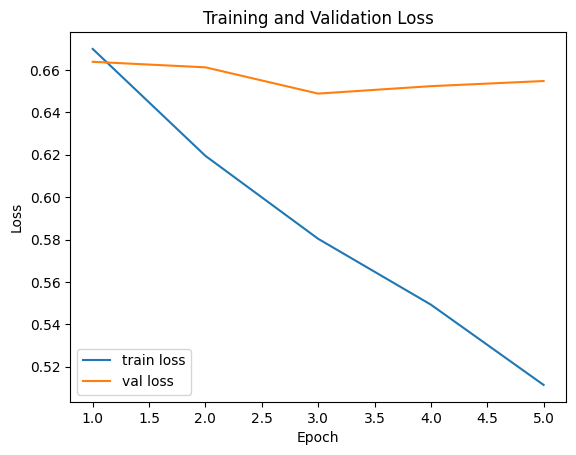

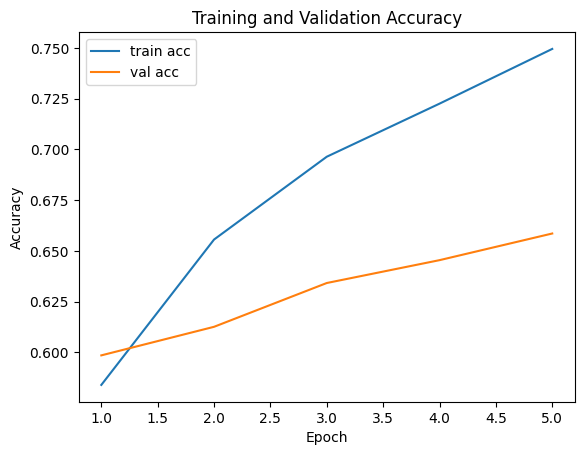

In [ ]:
# ===== Plot Training & Validation Loss =====

import matplotlib.pyplot as plt

# Get the actual number of epochs completed (due to early stopping)
epochs_completed = len(train_losses)

plt.figure()
plt.plot(range(1, epochs_completed + 1), train_losses, label="train loss")
plt.plot(range(1, epochs_completed + 1), val_losses, label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(range(1, epochs_completed + 1), train_accs, label="train acc")
plt.plot(range(1, epochs_completed + 1), val_accs, label="val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

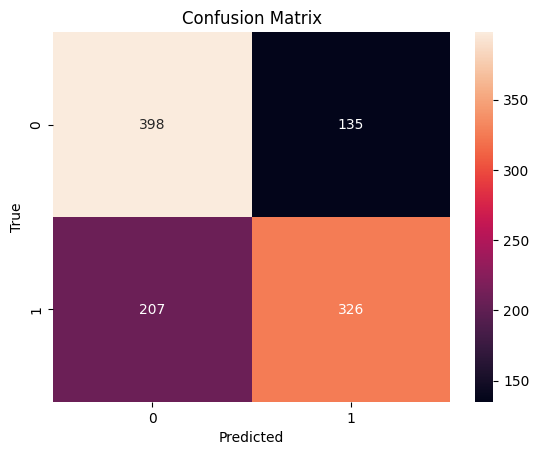

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
# Ensure the best model state is loaded before making test predictions
if best_model_state is not None:
    model.load_state_dict(best_model_state)
model.eval() # Set model to evaluation mode

true_labels = []
predictions = []

with torch.no_grad():
    for input_ids_b, attn_mask_b, labels_b in test_loader:
        input_ids_b = input_ids_b.to(device)
        attn_mask_b = attn_mask_b.to(device)
        labels_b    = labels_b.to(device)

        logits = model(input_ids_b, attn_mask_b)
        preds = torch.argmax(logits, dim=1)

        true_labels.extend(labels_b.cpu().numpy())
        predictions.extend(preds.cpu().numpy())

# Convert lists to numpy arrays
true_labels = np.array(true_labels)
preds = np.array(predictions)

# after test predictions
cm = confusion_matrix(true_labels, preds)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
# Load best model weights
if best_model_state is not None:
    model.load_state_dict(best_model_state)
print(f"Best epoch: {best_epoch}")
print(f"Best validation loss: {best_val_loss:.4f}")

Best epoch: 3
Best validation loss: 0.6489


In [ ]:
torch.save(best_model_state, "best_model4.pt")

In [ ]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Final Validation Accuracy: {val_acc:.4f}")
print(f"Final Test Accuracy: {test_acc: 4f}")
print(f"Final Test Loss: {test_loss:.4f}")

Final Validation Accuracy: 0.6585
Final Test Accuracy:  0.679174
Final Test Loss: 0.6002


In [ ]:
print ("Training Settings:")
print(f"Seed: 42")
print(f"Epochs: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Learning rate: 5e-4")
print(f"Max sequence length: 50")
print(f"d_model: 128")
print (f"num_heads: 8")
print(f"d_ff: 128")
print(f"num_layers: 1")

Training Settings:
Seed: 42
Epochs: 15
Batch size: 32
Learning rate: 5e-4
Max sequence length: 50
d_model: 128
num_heads: 8
d_ff: 128
num_layers: 1


In [ ]:
import json

config = {
    "seed": 42,
    "epochs": 15,
    "batch_size": 32,
    "learning_rate": 5e-4,
    "max_length": 50,
    "d_model": 128,
    "num_heads": 8,
    "d_ff": 128,
    "num_layers": 1,
    "patience": 2
}

with open("config_run4.json", "w") as f:
    json.dump(config, f, indent=4)

print("Config saved to config_run4.json")

Config saved to config_run4.json


In [ ]:
model = TransformerClassifier(
    vocab_size=len(word_to_id),
    d_model=128,
    num_heads=8,
    d_ff=128,
    num_layers=1
).to(device)

state_dict = torch.load("best_model4.pt", map_location=device)
model.load_state_dict(state_dict)
model.eval()


TransformerClassifier(
  (embed): InputEmbeddings(
    (embedding): Embedding(17422, 128, padding_idx=0)
  )
  (pos): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (layers): ModuleList(
    (0): TransformerEncoderBlock(
      (self_attention): MultiHeadAttention(
        (W_q): Linear(in_features=128, out_features=128, bias=True)
        (W_k): Linear(in_features=128, out_features=128, bias=True)
        (W_v): Linear(in_features=128, out_features=128, bias=True)
        (W_o): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (ffn): Sequential(
        (0): Linear(in_features=128, out_features=128, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_fe

In [ ]:
model = TransformerClassifier(
    vocab_size=len(word_to_id),
    d_model=128,
    num_heads=8,
    d_ff=128,
    num_layers=1
).to(device)

state_dict = torch.load("best_model4.pt", map_location=device)
model.load_state_dict(state_dict)
model.eval()


TransformerClassifier(
  (embed): InputEmbeddings(
    (embedding): Embedding(17422, 128, padding_idx=0)
  )
  (pos): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (layers): ModuleList(
    (0): TransformerEncoderBlock(
      (self_attention): MultiHeadAttention(
        (W_q): Linear(in_features=128, out_features=128, bias=True)
        (W_k): Linear(in_features=128, out_features=128, bias=True)
        (W_v): Linear(in_features=128, out_features=128, bias=True)
        (W_o): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (ffn): Sequential(
        (0): Linear(in_features=128, out_features=128, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_fe

# **Error Analysis**

In [ ]:
import numpy as np

# Find indices where the prediction does not match the true label
error_indices = np.where(true_labels != preds)[0]

print(f"Total misclassified examples found: {len(error_indices)}")

Total misclassified examples found: 342


In [ ]:
# Select the first 8 error indices
sample_errors = error_indices[:8]

print("--- 8 Misclassified Examples for Analysis ---")
for idx in sample_errors:
    # Get the cleaned text from your test dataframe
    original_text = df_test.iloc[idx]['cleaned_text']
    actual = true_labels[idx]
    predicted = preds[idx]

    print(f"Index: {idx}")
    print(f"Text: {original_text}")
    print(f"True Label: {actual} | Predicted: {predicted}")
    print("-" * 30)

--- 8 Misclassified Examples for Analysis ---
Index: 0
Text: lovingly photographed in the manner of a golden book sprung to life , stuart little 2 manages sweetness largely without stickiness .
True Label: 1 | Predicted: 0
------------------------------
Index: 2
Text: it's like a big chill reunion of the baader meinhof gang , only these guys are more harmless pranksters than political activists .
True Label: 1 | Predicted: 0
------------------------------
Index: 3
Text: the story gives ample opportunity for large scale action and suspense , which director shekhar kapur supplies with tremendous skill .
True Label: 1 | Predicted: 0
------------------------------
Index: 4
Text: red dragon never cuts corners .
True Label: 1 | Predicted: 0
------------------------------
Index: 6
Text: throws in enough clever and unexpected twists to make the formula feel fresh .
True Label: 1 | Predicted: 0
------------------------------
Index: 7
Text: weighty and ponderous but every bit as filling as the t